In [2]:
import sys
import pandas as pd
from pathlib import Path

# 1. Tell Jupyter where your root folder is so it can find 'src'
# (Path.cwd() gets the notebook's current folder, .parent.parent goes up to the root)
project_root = str(Path.cwd().parent.parent)
if project_root not in sys.path:
    sys.path.append(project_root)

# 2. Import your robust paths from your utils file
# (Change 'your_utils_file' to whatever you actually named the .py file in src/utils/)
from src.utils.paths import RAW_DATA_DIR

# 3. Read the dataset!
# The '/' operator perfectly joins your robust directory path to your file name
file_path = RAW_DATA_DIR / "C:\\Users\\Lenovo\\Documents\\Facultate\\Semestrul 3\\Predict_Introverts_From_Extroverts\\data\\raw\\train.csv"
df = pd.read_csv(file_path)

# View the first few rows to confirm it worked
df.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [17]:
# Assuming your dataset is already loaded into a variable named 'df'
import pandas as pd

if df.empty:
    print("Warning: The DataFrame is empty.")
else:
    # 1. Extract the raw data types into a DataFrame
    dtypes_df = df.dtypes.reset_index()
    dtypes_df.columns = ['Column', 'Data Type']

    # 2. Create a function to group them into human-readable categories
    def categorize_dtype(dt):
        if pd.api.types.is_numeric_dtype(dt):
            return 'Numeric'
        elif pd.api.types.is_datetime64_any_dtype(dt):
            return 'Datetime'
        elif pd.api.types.is_bool_dtype(dt):
            return 'Boolean'
        else:
            return 'Categorical / Text'

    # Apply the categorization
    dtypes_df['Category'] = df.dtypes.apply(categorize_dtype).values

    # 3. Calculate memory usage for each column (deep=True checks exact string lengths)
    mem_usage = df.memory_usage(deep=True, index=False).reset_index()
    mem_usage.columns = ['Column', 'Memory (Bytes)']

    # Merge the memory info with our dtypes table
    dtypes_df = pd.merge(dtypes_df, mem_usage, on='Column')

    # Convert Bytes to Megabytes for easier reading
    dtypes_df['Memory (MB)'] = (dtypes_df['Memory (Bytes)'] / (1024 * 1024)).round(4)
    dtypes_df = dtypes_df.drop(columns=['Memory (Bytes)'])

    # 4. Sort by Category so all your Numerics and Categoricals are grouped together
    dtypes_df = dtypes_df.sort_values(by=['Category', 'Column'])

    # Set the column name as the index for a cleaner look
    dtypes_df = dtypes_df.set_index('Column')

    # 5. Force Jupyter to render the table beautifully
    display(dtypes_df)

,Data Type,Category,Memory (MB)
Column,,,
Drained_after_socializing,object,Categorical / Text,0.8840
Personality,object,Categorical / Text,1.0246
Stage_fear,object,Categorical / Text,0.8705
Friends_circle_size,float64,Numeric,0.1413
Going_outside,float64,Numeric,0.1413
Post_frequency,float64,Numeric,0.1413
Social_event_attendance,float64,Numeric,0.1413
Time_spent_Alone,float64,Numeric,0.1413
id,int64,Numeric,0.1413


In [5]:
# Assuming your dataset is already loaded into a variable named 'df'

if df.empty:
    print("Warning: The DataFrame is empty.")
else:
    # 1. Calculate counts and percentages
    missing_count = df.isnull().sum()
    missing_percentage = (missing_count / len(df)) * 100

    # 2. Combine into a clean DataFrame
    missing_info = pd.concat(
        [missing_count, missing_percentage],
        axis=1,
        keys=['Missing Count', 'Missing Percentage (%)']
    )

    # 3. Filter out columns that have NO missing data
    missing_info = missing_info[missing_info['Missing Count'] > 0]

    # 4. Sort the worst offenders to the top
    missing_info = missing_info.sort_values(by='Missing Percentage (%)', ascending=False)

    # 5. Round the percentage for a cleaner display
    missing_info['Missing Percentage (%)'] = missing_info['Missing Percentage (%)'].round(2)

    # 6. Force Jupyter to render the table, even inside the 'else' block
    display(missing_info)

,Missing Count,Missing Percentage (%)
Stage_fear,1893,10.22
Going_outside,1466,7.91
Post_frequency,1264,6.82
Time_spent_Alone,1190,6.42
Social_event_attendance,1180,6.37
Drained_after_socializing,1149,6.20
Friends_circle_size,1054,5.69


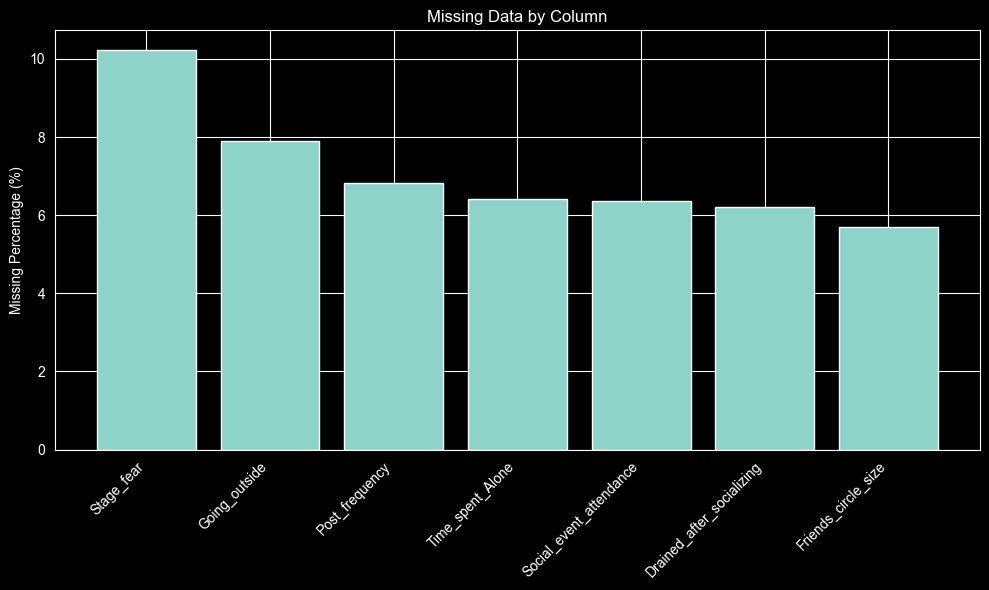

In [6]:
import matplotlib.pyplot as plt

if df.empty:
    print("Warning: The DataFrame is empty.")
else:
    missing_count = df.isnull().sum()
    missing_percentage = (missing_count / len(df)) * 100

    missing_info = pd.concat(
        [missing_count, missing_percentage],
        axis=1,
        keys=['Missing Count', 'Missing Percentage (%)']
    )

    missing_info = missing_info[missing_info['Missing Count'] > 0]
    missing_info = missing_info.sort_values(by='Missing Percentage (%)', ascending=False)
    missing_info['Missing Percentage (%)'] = missing_info['Missing Percentage (%)'].round(2)

    # ---- PLOT ----
    plt.figure(figsize=(10, 6))
    plt.bar(missing_info.index, missing_info['Missing Percentage (%)'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Missing Percentage (%)')
    plt.title('Missing Data by Column')
    plt.tight_layout()
    plt.show()

In [7]:
# Assuming your dataset is already loaded into a variable named 'df'
import numpy as np
import pandas as pd

if df.empty:
    print("Warning: The DataFrame is empty.")
else:
    # 1. Isolate only the numerical columns
    num_cols = df.select_dtypes(include=[np.number]).columns

    if len(num_cols) == 0:
        print("No numerical columns found to analyze for outliers.")
    else:
        outlier_data = []
        total_rows = len(df)

        # 2. Calculate the IQR and bounds for each numerical column
        for col in num_cols:
            # Drop NaNs just for the calculation so math doesn't break
            col_data = df[col].dropna()
            if col_data.empty:
                continue

            Q1 = col_data.quantile(0.25)
            Q3 = col_data.quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # 3. Count how many rows fall outside the bounds
            lower_outliers = (col_data < lower_bound).sum()
            upper_outliers = (col_data > upper_bound).sum()
            total_outliers = lower_outliers + upper_outliers

            # 4. Only keep data for columns that actually have outliers
            if total_outliers > 0:
                outlier_data.append({
                    'Column': col,
                    'Total Outliers': total_outliers,
                    'Outlier Percentage (%)': (total_outliers / total_rows) * 100,
                    'Lower Outliers': lower_outliers,
                    'Upper Outliers': upper_outliers,
                    'Lower Bound': lower_bound,
                    'Upper Bound': upper_bound
                })

        # 5. Combine into a clean DataFrame
        if not outlier_data:
            print("No outliers found in any numerical columns based on the 1.5 * IQR rule.")
        else:
            outlier_info = pd.DataFrame(outlier_data)

            # 6. Sort the columns with the most outliers to the top
            outlier_info = outlier_info.sort_values(by='Outlier Percentage (%)', ascending=False)

            # 7. Round the numbers for a cleaner display
            outlier_info['Outlier Percentage (%)'] = outlier_info['Outlier Percentage (%)'].round(2)
            outlier_info['Lower Bound'] = outlier_info['Lower Bound'].round(4)
            outlier_info['Upper Bound'] = outlier_info['Upper Bound'].round(4)

            # Set the column name as the index to make the table look much cleaner
            outlier_info = outlier_info.set_index('Column')

            # 8. Force Jupyter to render the table beautifully
            display(outlier_info)

,Total Outliers,Outlier Percentage (%),Lower Outliers,Upper Outliers,Lower Bound,Upper Bound
Column,,,,,,
Time_spent_Alone,1653,8.92,0,1653,-3.5,8.5


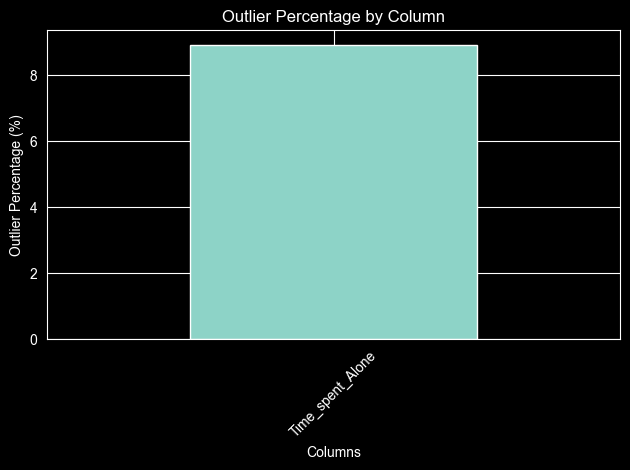

In [11]:
import matplotlib.pyplot as plt

# Ensure it's not empty
if not outlier_info.empty:
    plt.figure()

    outlier_info['Outlier Percentage (%)'].plot(kind='bar')

    plt.title('Outlier Percentage by Column')
    plt.xlabel('Columns')
    plt.ylabel('Outlier Percentage (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

In [12]:
# Assuming your dataset is already loaded into a variable named 'df'
import numpy as np
import pandas as pd

if df.empty:
    print("Warning: The DataFrame is empty.")
else:
    # 1. Isolate only the numerical columns
    num_cols = df.select_dtypes(include=[np.number]).columns

    if len(num_cols) == 0:
        print("No numerical columns found to analyze for skewness.")
    else:
        # 2. Calculate skewness using pandas built-in function
        # We drop NaNs temporarily just for the calculation
        skew_vals = df[num_cols].apply(lambda x: x.dropna().skew())

        # 3. Create a clean DataFrame
        skew_info = pd.DataFrame({'Skewness': skew_vals})

        # 4. Add a human-readable interpretation
        def interpret_skew(val):
            if pd.isna(val):
                return "Not enough data"
            elif abs(val) > 1.0:
                return "Highly Skewed (Consider log transformation)"
            elif abs(val) > 0.5:
                return "Moderately Skewed"
            else:
                return "Fairly Symmetrical"

        skew_info['Interpretation'] = skew_info['Skewness'].apply(interpret_skew)

        # 5. Sort by the most extreme skewness (absolute value)
        skew_info['Absolute Skew'] = skew_info['Skewness'].abs()
        skew_info = skew_info.sort_values(by='Absolute Skew', ascending=False)
        skew_info = skew_info.drop(columns=['Absolute Skew']) # Drop the helper column

        # 6. Clean up the display
        skew_info['Skewness'] = skew_info['Skewness'].round(3)
        skew_info.index.name = 'Column'

        # 7. Force Jupyter to render the table beautifully
        display(skew_info)

,Skewness,Interpretation
Column,,
Time_spent_Alone,1.134,Highly Skewed (Consider log transformation)
Going_outside,-0.367,Fairly Symmetrical
Social_event_attendance,-0.229,Fairly Symmetrical
Post_frequency,-0.059,Fairly Symmetrical
Friends_circle_size,-0.052,Fairly Symmetrical
id,0.000,Fairly Symmetrical


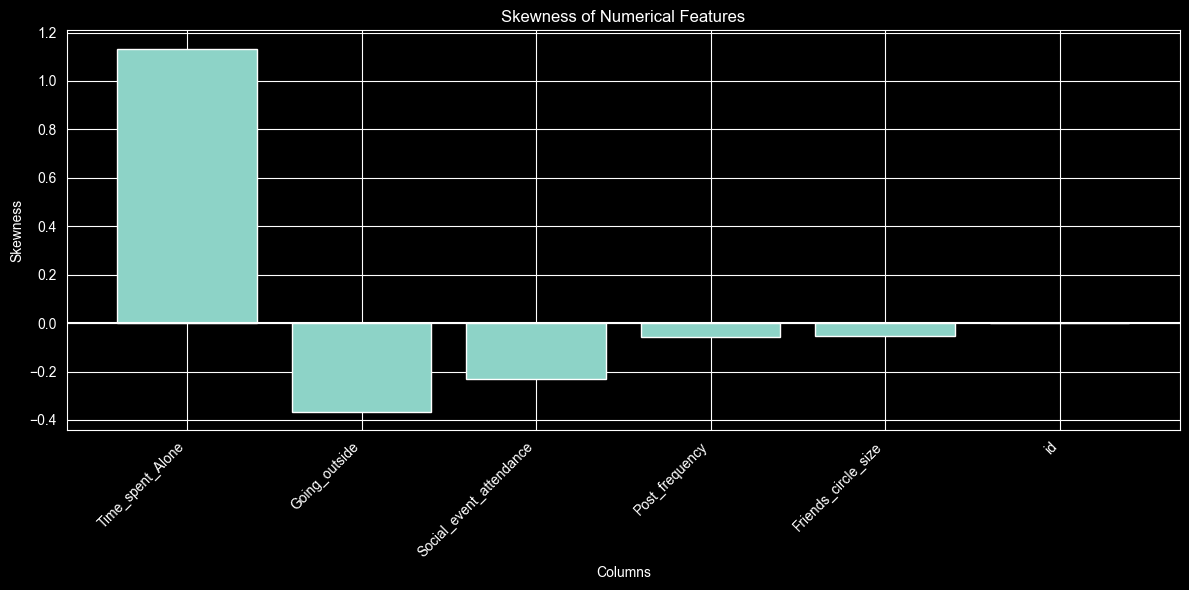

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(skew_info.index, skew_info['Skewness'])

# Reference line at 0 (perfect symmetry)
plt.axhline(0)

# Labels and title
plt.xlabel("Columns")
plt.ylabel("Skewness")
plt.title("Skewness of Numerical Features")

# Rotate column names for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()